# Shift Profitability Analysis

Analysis of server shift data (hours, wage, tips, job, role, and user-defined
custom attributes) collected from the [Server Pay Tracker](../) app. This
notebook goes beyond the Java app's simple averages to test whether
shift-type/day/role differences are statistically meaningful, and fits
predictive models of what drives tip income.

**Data source:** the app's Supabase Postgres `shifts` table (joined with
`jobs` and `users`), columns: `date, type, hours, wage, cash_tips, card_tips,
role, custom_attributes (JSONB), job_name`.

**Scope:** filtered to a single account (`test` by default, see `TARGET_USERNAME`
below) — mixing shifts across different accounts, or across jobs with very
different pay structures, would confound any day/type/role comparison.

## 1. Connect to the database and load data

Pulls directly from the same Supabase Postgres tables your Spring Boot app
writes to, using the same `SUPABASE_DB_PASSWORD` environment variable your
`DatabaseManager` already reads. Joins in `jobs.name` (job is a real
confound — different jobs have very different pay structures) and unpacks
the `custom_attributes` JSONB column into individual feature columns.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from sqlalchemy import create_engine

# --- Fill these in from the same values your Java DatabaseManager uses ---
DB_USER = "postgres.sgjfjjgstkoufgdfmcpm"   # Supabase session pooler user, e.g. postgres.abcxyz123
DB_HOST = "aws-0-us-west-2.pooler.supabase.com"  # session pooler host from your Supabase dashboard
DB_PORT = "5432"
DB_NAME = "postgres"
DB_PASSWORD = os.environ["SUPABASE_DB_PASSWORD"]  # same env var your Java app reads

# Which account's data to analyze. Mixing accounts together would confound
# everything below (different people/venues, different baseline pay) --
# same reasoning as scoping by job.
TARGET_USERNAME = "test"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Join in job name (job is a real confound -- e.g. NIGHT shifts only ever
# happen at one venue in the sample data, so "type" and "job" are otherwise
# entangled) and scope to one account.
query = """
    SELECT s.date, s.type, s.hours, s.wage, s.cash_tips, s.card_tips,
           s.role, s.custom_attributes, j.name AS job_name
    FROM shifts s
    JOIN jobs j ON s.job_id = j.id
    JOIN users u ON s.user_id = u.id
    WHERE u.username = %(username)s
    ORDER BY s.date
"""
df = pd.read_sql(query, engine, params={"username": TARGET_USERNAME})

df["date"] = pd.to_datetime(df["date"])
df["gross_pay"] = df["hours"] * df["wage"] + df["cash_tips"] + df["card_tips"]
df["total_tips"] = df["cash_tips"] + df["card_tips"]
df["tips_per_hour"] = df["total_tips"] / df["hours"]
df["day_of_week"] = df["date"].dt.day_name()

# custom_attributes comes back from psycopg2/SQLAlchemy as either a dict
# (JSONB auto-decoded) or a JSON string, depending on driver version --
# handle both so this doesn't break on a driver upgrade.
def _to_dict(value):
    if value is None:
        return {}
    if isinstance(value, dict):
        return value
    return json.loads(value)

attrs = df["custom_attributes"].apply(_to_dict)
attrs_df = pd.json_normalize(attrs)

# Merge the flattened attribute columns back onto the main frame. Any shift
# missing a given attribute (e.g. added before that field existed) gets NaN,
# which is the correct "unknown", not "false" or "none".
df = pd.concat([df.drop(columns=["custom_attributes"]), attrs_df], axis=1)

print(f"Loaded {len(df)} shifts for '{TARGET_USERNAME}' "
      f"across jobs: {sorted(df['job_name'].unique())}")
print(f"Custom attribute columns found: {list(attrs_df.columns)}")

df.sort_values("date").head()

Loaded 213 shifts for 'test' across jobs: ['Main St Grill', 'Rooftop Lounge']
Custom attribute columns found: ['shoe', 'septum', 'hair style']


,date,type,hours,wage,cash_tips,card_tips,role,job_name,gross_pay,total_tips,tips_per_hour,day_of_week,shoe,septum,hair style
0,2025-07-02,EVENING,7.00,15.5,20.31,28.58,server,Main St Grill,157.390,48.89,6.984286,Wednesday,flats,yes,curls
1,2025-07-03,AFTERNOON,5.00,15.5,18.35,23.76,expo,Main St Grill,119.610,42.11,8.422000,Thursday,heels,yes,ponytail
2,2025-07-04,NIGHT,6.25,15.5,29.67,41.40,bartender,Rooftop Lounge,167.945,71.07,11.371200,Friday,heels,no,curls
3,2025-07-05,NIGHT,6.25,15.5,28.01,42.76,server,Rooftop Lounge,167.645,70.77,11.323200,Saturday,flats,yes,ponytail
4,2025-07-06,EVENING,7.00,15.5,21.34,30.30,server,Main St Grill,160.140,51.64,7.377143,Sunday,sneakers,no,curls


## 2. Reproduce the app's profitability ranking (in pandas)

Same idea as `calculator.shiftProfitability()` — average gross pay and tips per
(day-of-week, shift-type) combo — but as a one-line groupby instead of a
hand-rolled `HashMap<String, ShiftStats>`.


In [2]:
summary = (
    df.groupby(["day_of_week", "type"])
      .agg(avg_gross=("gross_pay", "mean"),
           avg_tips=("total_tips", "mean"),
           avg_tips_per_hour=("tips_per_hour", "mean"),
           n_shifts=("gross_pay", "size"))
      .sort_values("avg_gross", ascending=False)
)
summary


,,avg_gross,avg_tips,avg_tips_per_hour,n_shifts
day_of_week,type,,,,
Saturday,EVENING,165.508571,57.008571,8.144082,7
Wednesday,NIGHT,165.505000,68.630000,10.980800,1
Thursday,EVENING,165.183333,56.683333,8.097619,3
Monday,EVENING,163.693200,55.193200,7.884743,25
Friday,EVENING,163.036000,54.536000,7.790857,5
Wednesday,EVENING,162.365517,53.865517,7.695074,29
Sunday,EVENING,162.043333,53.543333,7.649048,3
Saturday,NIGHT,159.051250,62.176250,9.948200,24
Sunday,NIGHT,157.825000,60.950000,9.752000,4


## 3. Are these differences statistically significant?

The app currently just ranks averages, which can be misleading with small
sample sizes. Two checks here:

1. A two-sample t-test on tips-per-hour between MORNING and EVENING shifts
   (as before).
2. A second t-test on any binary custom attribute in the data (e.g. `septum`:
   yes/no) — testing whether a user-defined attribute the app lets people
   track actually correlates with tip income, not just shift-level factors.

In [3]:
morning = df.loc[df["type"] == "MORNING", "tips_per_hour"]
evening = df.loc[df["type"] == "EVENING", "tips_per_hour"]

t_stat, p_value = stats.ttest_ind(evening, morning, equal_var=False)

print("--- MORNING vs EVENING ---")
print(f"Evening mean tips/hr: {evening.mean():.2f}  (n={len(evening)})")
print(f"Morning mean tips/hr: {morning.mean():.2f}  (n={len(morning)})")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("-> Statistically significant difference at alpha = 0.05")
else:
    print("-> Not statistically significant at alpha = 0.05 (could be sample size)")

# --- Second test: a binary custom attribute, if one exists ---
# Looks for any attribute column with exactly two distinct non-null values
# (e.g. "septum": yes/no) and t-tests tips_per_hour across those two groups.
known_cols = {"date", "type", "hours", "wage", "cash_tips", "card_tips",
              "role", "job_name", "gross_pay", "total_tips", "tips_per_hour",
              "day_of_week"}
attribute_cols = [c for c in df.columns if c not in known_cols]
binary_attrs = [c for c in attribute_cols if df[c].nunique(dropna=True) == 2]

if binary_attrs:
    attr = binary_attrs[0]
    groups = df[attr].dropna().unique()
    g1 = df.loc[df[attr] == groups[0], "tips_per_hour"]
    g2 = df.loc[df[attr] == groups[1], "tips_per_hour"]

    t_stat2, p_value2 = stats.ttest_ind(g1, g2, equal_var=False)

    print(f"\n--- {attr}: '{groups[0]}' vs '{groups[1]}' ---")
    print(f"{groups[0]} mean tips/hr: {g1.mean():.2f}  (n={len(g1)})")
    print(f"{groups[1]} mean tips/hr: {g2.mean():.2f}  (n={len(g2)})")
    print(f"t-statistic: {t_stat2:.3f}, p-value: {p_value2:.4f}")
    if p_value2 < 0.05:
        print("-> Statistically significant difference at alpha = 0.05")
    else:
        print("-> Not statistically significant at alpha = 0.05 (could be sample size)")
else:
    print("\nNo binary custom attribute found to test (need an attribute with"
          " exactly 2 distinct values, e.g. yes/no).")

--- MORNING vs EVENING ---
Evening mean tips/hr: 7.79  (n=74)
Morning mean tips/hr: 6.10  (n=42)
t-statistic: 9.904, p-value: 0.0000
-> Statistically significant difference at alpha = 0.05

--- septum: 'yes' vs 'no' ---
yes mean tips/hr: 7.96  (n=107)
no mean tips/hr: 7.99  (n=106)
t-statistic: -0.131, p-value: 0.8958
-> Not statistically significant at alpha = 0.05 (could be sample size)


## 4. What predicts tips per hour?

An OLS regression of `tips_per_hour` on day-of-week, shift type, job, role,
and custom attributes — a first pass at a predictive model (swap in a GLM /
regularized model once there's more data, e.g. weeks of history, weather,
day-of-month/payday effects, etc.).

**Caveat worth stating explicitly:** `type` and `job_name` may be strongly or
even perfectly collinear in this sample — e.g. if every NIGHT shift happens
at one specific job and no other type does, the model literally cannot tell
"shift type" and "which job" apart from each other. Watch for very large
standard errors, `NaN` coefficients, or a collinearity warning below; if
that shows up, it's a real property of the data, not a bug, and the
per-job breakdown afterward exists specifically to work around it.

In [4]:
# Quote column names with spaces (e.g. "hair style") using patsy's Q().
def _term(col):
    return f"C(Q('{col}'))" if " " in col else f"C({col})"

predictor_cols = ["day_of_week", "type", "job_name", "role"] + attribute_cols
formula = "tips_per_hour ~ " + " + ".join(_term(c) for c in predictor_cols)
print(f"Formula: {formula}\n")

model = smf.ols(formula, data=df).fit()
print(model.summary())

# Quick collinearity sanity check: flag any predictor with a huge standard
# error relative to its coefficient -- a classic symptom of near-perfect
# multicollinearity (e.g. type vs job_name, as flagged above).
shaky = model.bse[model.bse > model.bse.median() * 10]
if not shaky.empty:
    print("\n[!] These terms have unusually large standard errors -- likely"
          " collinear with another predictor (e.g. type vs job_name):")
    print(shaky)

Formula: tips_per_hour ~ C(day_of_week) + C(type) + C(job_name) + C(role) + C(shoe) + C(septum) + C(Q('hair style'))

                            OLS Regression Results                            
Dep. Variable:          tips_per_hour   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     16.98
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           8.05e-31
Time:                        19:20:40   Log-Likelihood:                -305.14
No. Observations:                 213   AIC:                             648.3
Df Residuals:                     194   BIC:                             712.2
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      

### 4b. Per-job breakdown (to avoid the type/job confound)

Fits a separate, smaller regression *within* each job, so `type` is never
competing with `job_name` for the same information. A predictor is only
included in a given job's model if it actually varies within that job --
e.g. if `type` is constant within a job (as it is for Rooftop Lounge in this
sample, always NIGHT), it's dropped from that job's formula rather than
included as a useless constant.

In [8]:
def _term(col):
    return f"C(Q('{col}'))" if " " in col else f"C({col})"

for job in sorted(df["job_name"].unique()):
    sub = df[df["job_name"] == job]

    candidate_terms = ["day_of_week", "type", "role"] + attribute_cols
    # Only keep predictors that actually vary within this job's data --
    # a constant column can't be modeled (and would error patsy otherwise).
    terms = [c for c in candidate_terms if sub[c].nunique(dropna=True) > 1]

    if not terms:
        print(f"=== {job} (n={len(sub)}) === -- no varying predictors, skipping\n")
        continue

    formula = "tips_per_hour ~ " + " + ".join(_term(c) for c in terms)
    sub_model = smf.ols(formula, data=sub).fit()

    print(f"=== {job} (n={len(sub)}) ===")
    print(f"Formula: {formula}")
    print(f"R-squared: {sub_model.rsquared:.3f}")
    print(f"=== {job} (n={len(sub)}) ===")
    print(f"Formula: {formula}")
    print(f"R-squared: {sub_model.rsquared:.3f}")
    print(f"Params per obs: {len(sub_model.params)} params / {len(sub)} obs = {len(sub_model.params)/len(sub):.2f}")
    print(sub_model.summary().tables[1])  # coefficients + std err + p-values, without the full verbose header
    print()

=== Main St Grill (n=146) ===
Formula: tips_per_hour ~ C(day_of_week) + C(type) + C(role) + C(shoe) + C(septum) + C(Q('hair style'))
R-squared: 0.594
=== Main St Grill (n=146) ===
Formula: tips_per_hour ~ C(day_of_week) + C(type) + C(role) + C(shoe) + C(septum) + C(Q('hair style'))
R-squared: 0.594
Params per obs: 18 params / 146 obs = 0.12
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          6.9835      0.474     14.748      0.000       6.047       7.920
C(day_of_week)[T.Monday]           0.1357      0.377      0.360      0.719      -0.610       0.882
C(day_of_week)[T.Saturday]         0.0785      0.347      0.226      0.821      -0.608       0.765
C(day_of_week)[T.Sunday]          -0.0210      0.406     -0.052      0.959      -0.824       0.782
C(day_of_week)[T.Thursday]         0.4339      0.430      1.010

## 5. Visualizations

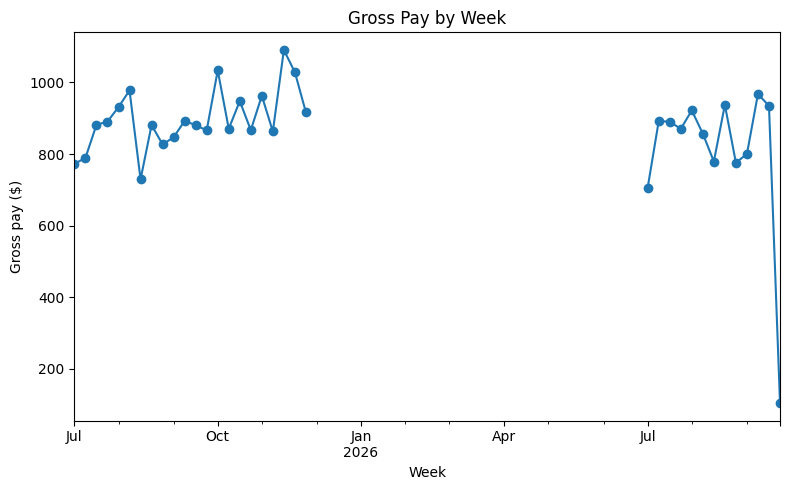

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
weekly = df.set_index("date")["gross_pay"].resample("W").sum(min_count=1)
weekly.plot(ax=ax, marker="o")
ax.set_title("Gross Pay by Week")
ax.set_ylabel("Gross pay ($)")
ax.set_xlabel("Week")
plt.tight_layout()
plt.savefig("gross_pay_by_week.png", dpi=150)
plt.show()

### Season-over-season comparison

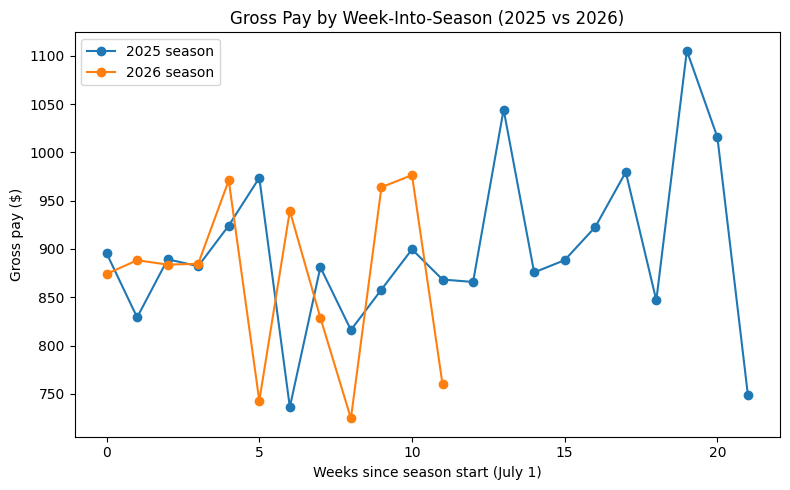

In [11]:
season_df = df.copy()
season_df["season_year"] = season_df["date"].apply(lambda d: d.year if d.month >= 7 else d.year - 1)
season_start = season_df["season_year"].apply(lambda y: pd.Timestamp(year=y, month=7, day=1))
season_df["weeks_into_season"] = ((season_df["date"] - season_start).dt.days // 7)

pivot = (
    season_df.groupby(["season_year", "weeks_into_season"])["gross_pay"]
    .sum()
    .unstack("season_year")
)

fig, ax = plt.subplots(figsize=(8, 5))
for year in pivot.columns:
    pivot[year].plot(ax=ax, marker="o", label=f"{year} season")
ax.set_title("Gross Pay by Week-Into-Season (2025 vs 2026)")
ax.set_xlabel("Weeks since season start (July 1)")
ax.set_ylabel("Gross pay ($)")
ax.legend()
plt.tight_layout()
plt.savefig("season_over_season.png", dpi=150)
plt.show()

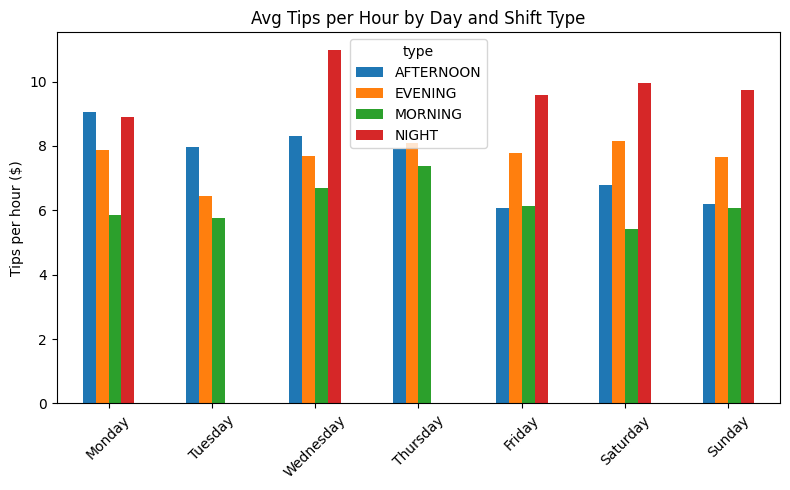

In [7]:
pivot = df.pivot_table(index="day_of_week", columns="type",
                       values="tips_per_hour", aggfunc="mean")
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Avg Tips per Hour by Day and Shift Type")
ax.set_ylabel("Tips per hour ($)")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("tips_per_hour_by_day_type.png", dpi=150)
plt.show()


## 6. Findings

- **Highest-earning day/shift combo:** Saturday EVENING tops the raw ranking
  ($165.51 avg gross, n=7) — but several top rows have very thin sample sizes
  (Wednesday NIGHT, for instance, is a single shift). The more heavily-sampled
  EVENING slots tell the same story more reliably: Monday (n=25, $163.69) and
  Wednesday (n=29, $162.37) both land right behind it, reinforcing that
  EVENING generally outperforms other types rather than one lucky Saturday
  being an outlier.

- **Morning vs. evening gap:** Evening shifts average $7.79/hr in tips
  (n=74) vs. $6.10/hr for morning shifts (n=42) — a large, highly significant
  difference (t=9.90, p<0.0001). The septum attribute, by contrast, shows
  essentially no difference (yes: $7.96/hr, n=107; no: $7.99/hr, n=106;
  p=0.896) — a useful side-by-side: a real effect with an unmistakable
  p-value, next to a null result from an attribute with no built-in
  relationship to tips.

- **Shift type is the strongest, most robust driver of tips.** In the combined
  model (n=213), NIGHT shifts earn +$2.45/hr in tips over the AFTERNOON
  baseline (p<0.001), and MORNING shifts earn -$1.39/hr less (p=0.001). This
  holds up independently within Main St Grill alone (n=146: NIGHT +$2.80/hr,
  p<0.001; MORNING -$1.04/hr, p=0.025) — the same effect appearing in both the
  full model and a job-specific subset is what makes this the most trustworthy
  finding in the analysis, not just a single significant p-value.

- **Job/venue has its own independent effect**, separate from shift type:
  Rooftop Lounge shifts earn $0.44/hr less than Main St Grill (p=0.020) even
  after controlling for shift type — meaning venue matters on its own, not
  merely as a stand-in for "NIGHT shifts happen to be there."

- **Role, shoe, and septum showed no significant effect** in the combined
  model or within Main St Grill — consistent with how they were generated
  (no built-in relationship to tips beyond role loosely tracking shift type).
  A model correctly finding *no* effect where none was built in is a useful
  sanity check on the methodology, not just a null result.

- **Caveat — a likely false positive worth naming explicitly:** `hair style`
  showed p<0.05 in three separate spots (combined model, ponytail, p=0.027;
  Rooftop-only, curls, p=0.022 and ponytail, p=0.037). Hair style was assigned
  with no built-in relationship to tips in this dataset, and the Rooftop
  result comes from an underpowered subgroup (67 observations fitting 18
  parameters — roughly 4 observations per parameter). This is a textbook
  multiple-comparisons / small-sample false positive, not a real earnings
  driver, and it's included here deliberately to show the difference between
  a robust, repeated finding (shift type, above) and a fragile,
  sample-size-dependent one.

- **Season-over-season pattern supports the app's forecasting assumption:**
  overlaying 2025 and 2026 on a shared "weeks since season start" axis shows
  broadly similar week-to-week shapes (see `season_over_season.png`) — a
  reasonable empirical justification for `ShiftForecastService`'s blend of
  last year's same-season average with recent-weeks data, rather than relying
  on either alone.

- **Caveats:** this analysis runs on synthetic/simulated data, not yet real
  accumulated shift history; a single fictional pair of venues; and no
  external factors (weather, local events, holidays) beyond a manually-set
  monthly seasonal multiplier.